#### Trajectory Optimisation

Initial path to see effect of grasp primitives. Then, depending on results, extend to RL.

In this code, the trajectory from the baseline experiment is optimised, which composed by 3 sections: back by distance d, forth by distande 2d and diagonal.

Therefore, this code optimises these 3 speeds for each segment, as well as obtain the maximum allowed speeds to place cloth flat.

Moreover, the repeatability of the optimizer is checked in this code by running same optimisation with same seed for several experiments, and compare the optimal speeds among them -> RESULT: same optimal speeds if ran with same random seed !!!

Import all the functions needed for simulation and wrinkliness calculations, from the 'Final_vesrion_analysis' code.

In [1]:
import sys,os
notebook_dir = os.getcwd()  
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
print(parent_dir)
from implementation.Cloth import Cloth 
from implementation.utils import createRectangularMesh
import time
import numpy as np

import polyscope as ps

import matplotlib.pyplot as plt

/Users/patriserratosa/Desktop/IRI/Thesis/Cloth Simulation Autocollisions (v2)/python_code


In [2]:
# -------------------------
# CLOTH TYPES
# -------------------------

CLOTH_TYPES = {

    "RL": {  # Rigid-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EL": {  # Elastic-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "RH": {  # Rigid-Heavy
        "tol": 0.0075,
        "rho": 0.4,
        "delta": 0.4,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EH": {  # Elastic-Heavy
        "tol": 0.0075,
        "rho": 0.3,
        "delta": 0.3,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "M": {  # In-between
        "tol": 0.0075,
        "rho": 0.2,
        "delta": 0.2,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 1e-4,
        "str": 0.01e-4,
        "thck": 0.9,
    },
}

# cloth_list = ["RL", "EL", "RH", "EH", "M"] # add more cloth types

In [3]:
def get_grasp_config(name, na):
    
    if name == "G1":
        return [0, na-1]
    
    elif name == "G2":
        return [0, 1, na, na+1, na-2, na-1, 2*na-2, 2*na-1]

    elif name == "G3":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) +
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1))
        )
    
    elif name == "G4":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) + 
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1)) + 
            list(range(int((na/4)-2+na), int((na/4)+2+na)+1)) + 
            list(range(int(3*(na/4)-2+na), int(3*(na/4)+2+na)+1))
        )
    
    elif name == "G5":
        return list(range(int((na/6)), int(5*(na/6))))

    elif name == "G6":
        return list(range(int((na/4))+1, int(3*(na/4))))

    else:
        raise ValueError("Unknown grasp configuration")

In [4]:
a=0.6
b=0.9
na=20
nb = int(na * (1 + a/b))
print(nb)

33


In [5]:
def create_initial_mesh(a=0.6, b=0.9, na=20): # limit nº of nodes to avoid long simulation times andmore stable results
    nb = int(na * (1 + a/b))
    
    X, T = createRectangularMesh(a=a, b=b, na=na, nb=nb, h=0.1)

    # Rotate -90° around X-axis
    theta = -np.pi / 2
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(theta), -np.sin(theta)],
                   [0, np.sin(theta), np.cos(theta)]])
    X = X @ Rx.T

    # Raise above table
    X[:, 2] += 0.50

    return X, T, na, nb  # also return na, nb if needed

In [6]:
def run_experiment(cloth_type_name, grasp_name):

    X, T, na, nb = create_initial_mesh()  # returns all these 4 values
    name = f"{cloth_type_name}_{grasp_name}"
    clothilde = Cloth(X, T, name)  # Original X unchanged

    # compute a suitable timestep based on the mesh
    dt = clothilde.estimateTimeStep(L=0.9)  # largest lineal length of the mesh

    ## ---------------- Experiment Definition ---------------- ##

    params = CLOTH_TYPES[cloth_type_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    clothilde.preparePolyscope()  # need this to save frames and use polyscope!!

    # use keyword arguments so that ordering mistakes can't occur
    clothilde.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )

    clothilde.restart()

    ## ---------------- Trajectory ---------------- ##

    # Initial position
    u = clothilde.positions[inds_ctr]
    center = u.mean(axis=0) # Get the center by doing the mean of the node positions (column-wise mean to get single 3D point = geometric center of controlled nodes)
    u = center + (u-center) * 0.95 # will decrease the distance from center by keeping the 0.95 (=95%) of the original distance
    for i in range(200): # 200 iterations x 0.005 seconds (dt = time step) = 1 seconds of simulated time 
       clothilde.simulate(u = u, control = inds_ctr) # increment this section to let the cloth stabilize before starting trajectory
    
    # move it backward
    u = clothilde.positions[inds_ctr]
    for i in range(50): 
        u[:,1] += 0.004 # sums every time step to move backward
        clothilde.simulate(u = u, control = inds_ctr)

    # move it forward a bit
    u = clothilde.positions[inds_ctr]
    for i in range(100): 
        u[:,1] -= 0.004 # subs every time step, but less than above 
        clothilde.simulate(u = u, control = inds_ctr)

    # move it down + forward until reaching table (in Y, needs to go down by b = 0.9 + the adjusting initial height of 0.1, so total of 1)
    u = clothilde.positions[inds_ctr]
    # need Euler angles to do both movements at the same time
    for i in range(265): # 160 iterations x 0.005 seconds (dt = time step) = 0.8 seconds of simulated time
        u[:,1] -= 0.0018 # subs every time step at Z, so does total of 0.416 forward
        u[:,2] -= 0.00358 # sums every time step, so it totally moves 1 down at Y
        clothilde.simulate(u = u, control = inds_ctr)

    # stop sequence and motion
    inds_ctr = [] # release controlled nodes at the end
    u = clothilde.positions[inds_ctr]
    for i in range(400): # 100 iterations x 0.005 seconds (dt = time step) = 0.5 seconds of simulated time
        clothilde.simulate(u = u, control = inds_ctr)
    
    return np.array(clothilde.history_pos), clothilde.Am, clothilde.label, clothilde.faces # need history for plotting and also Am for the video

In [7]:
# before calling this function, we need to do 
# V = Am @ history[-1] -> reconstruction of the final position of the mesh with more resolution using Am

def compute_wrinkle_sigma(V, k=20):
    """
    Compute surface variation (wrinkle intensity) per vertex.

    Parameters:
        V : (N,3) array of vertex positions
        k : number of nearest neighbors

    Returns:
        sigma : (N,) wrinkle intensity values
    """

    N = V.shape[0]
    sigma = np.zeros(N) # vector to store wrinkle intensity for each vertex

    for i in range(N): # loop over each vertex

        # Compute distances to all other points
        diff = V - V[i] # vector from v_i to all other vertices
        dist2 = np.sum(diff**2, axis=1) # squared Euclidean distancew

        # Get k nearest neighbors (excluding itself)
        idx = np.argsort(dist2)[1:k+1] # sort all distances and pick the k closest neighbors
        neighbors = V[idx]

        # Compute local mean to get centroid of neighborhood
        mean = np.mean(neighbors, axis=0)

        # Compute covariance matrix
        centered = neighbors - mean # center points around mean (shift neighbors to centroid)
        C = centered.T @ centered / k # covariance matrix of the neighborhood (3x3) captures local geometry around vertex i

        # Eigenvalues (symmetric matrix)
        eigvals = np.linalg.eigvalsh(C)
        # Sort them ascending 
        lambda1, lambda2, lambda3 = eigvals[2], eigvals[1], eigvals[0]

        # Surface variation = wrinkle intensity
        sigma[i] = lambda3 / (lambda1 + lambda2 + lambda3 + 1e-12)

    return sigma


In [8]:
def vertex_areas(V, F):
    """
    Compute approximate area around each vertex for a quad mesh.
    
    V: (n_verts, 3) vertex positions
    F: (n_faces, 4) quad faces (vertex indices)
    """
    areas = np.zeros(V.shape[0])
    
    # split quads into 2 triangles for area computation
    tris = np.vstack([F[:, [0,1,2]], F[:, [0,2,3]]])
    
    for tri in tris:
        v0, v1, v2 = V[tri[0]], V[tri[1]], V[tri[2]]
        tri_area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        areas[tri] += tri_area / 3  # distribute equally to 3 vertices
        
    return areas

In [9]:
def compute_wrinkle_metric_area(V, F, sigma):
    areas = vertex_areas(V, F)
    
    # weighted mean
    W_global = np.sum(sigma * areas) / np.sum(areas)
    
    return W_global

1) Displacements of the trajectory (manually calculated based on time steps and distances taken at each)

All experiments have the same setting, so no need to change this values further on the code.

These definitions are manually done based on distances of trajectory, so if trajectory changes, we need to change all this (d's and L's)!!

In [10]:
# Constants (calculated from baseline experiment)
# representing the travelled distance at each phase (for each axis))
d_back = np.array([0.0, 0.2, 0.0])
d_forward = np.array([0.0, -0.2, 0.0])
d_end = np.array([0.0, -0.8, -0.93]) # coords after diagonal motion (moves 0.6 forth and 0.93 down)

# total linear displacement
L1 = 0.2
# for  1rst case opt., L2 = 2*L1
L2 = 2*L1
L3 = np.sqrt(0.6**2 + 0.93**2)
L_total = L1 + L2 + L3
lam_a = L1 / L_total
lam_b = (L1 + L2) / L_total

# Divide trajectory by phases, not by equidistant sections
lam_knots = np.array([0.0, lam_a, lam_b, 1.0]) # want to separate trajectory into the 3 motion-phases in sim. (back-forth-diag)

2) Function that gives the displacement from the starting point to that phase lambda so far, along the trajectory.

The trajectory has been divided into 4 points: starting point, point where 1rst move ends, point where 2nd move ends and ending point. It si defined by lam_knots above.

In [11]:
def path_displacement(lam):
    """Return displacement from start for a given phase lam."""
    if lam <= lam_a: # backward phase
        alpha = lam / lam_a
        return alpha * d_back
    elif lam <= lam_b: # forward phase
        alpha = (lam - lam_a) / (lam_b - lam_a)
        return d_back + alpha * (d_forward - d_back)
    else: # diagonal phase
        alpha = (lam - lam_b) / (1.0 - lam_b)
        return d_forward + alpha * (d_end - d_forward)

3) Parametrise the Speed Profile: v(lam) is in units of lam per second to be piecewise linear function of lam.

Control points are just a few, at lam = [0, lam_a, lam_b, 1], so starting, 2 middle and ending points along the path, which corresponds to the 3 different controls in the whole trajectory.

The speeds at these points are the optimisation parameters. BUT THE INITIAL KNOT IS FIXED TO 0 (gripper starts still).

The speed between knots points is linearly interpolated using the start-end knots of the motion phase.

Given a set of speeds, we can generate the sequence of λ values at each simulation time step by integrating forward:

In [12]:
def generate_lambda_sequence(speeds, lam_knots, dt, max_steps=5000):
    """
    speeds: array of speeds at lam_knots
    lam_knots: array of lambda coordinates of control points
    dt: simulation time step
    Returns: list of lambda values at each simulation step (including start and end)
    """
    lam = 0.0
    lam_seq = [lam]
    step = 0
    while lam < 1.0 and step < max_steps:
        # interpolate speed at current lam
        idx = np.searchsorted(lam_knots, lam) - 1
        if idx == len(lam_knots) - 1:
            v = speeds[-1]
        else:
            lam_left = lam_knots[idx]
            lam_right = lam_knots[idx+1]
            v_left = speeds[idx]
            v_right = speeds[idx+1]
            if lam_right > lam_left:
                alpha = (lam - lam_left) / (lam_right - lam_left)
            else:
                alpha = 0.0
            v = v_left + alpha * (v_right - v_left)
        lam += v * dt
        lam_seq.append(lam)
        step += 1
    if lam_seq[-1] > 1.0:
        lam_seq[-1] = 1.0
    return lam_seq

Speeds are constant for each segment, no interpolation done between knot points.

In [13]:
def generate_lambda_sequence(speeds, lam_knots, dt, max_steps=5000):
    """
    speeds: array of speeds at lam_knots (constant per segment)
    lam_knots: array of lambda coordinates of control points
    dt: simulation time step
    Returns: list of lambda values at each simulation step
    """
    lam = 0.0
    lam_seq = [lam]
    step = 0
    
    while lam < 1.0 and step < max_steps:
        # Encuentra en qué segmento estamos
        idx = np.searchsorted(lam_knots, lam, side='right') - 1
        idx = np.clip(idx, 0, len(speeds) - 1)
        
        # Velocidad CONSTANTE del segmento actual (sin interpolación)
        v = speeds[idx]
        
        lam += v * dt
        lam_seq.append(lam)
        step += 1
    
    if lam_seq[-1] > 1.0:
        lam_seq[-1] = 1.0
    
    return lam_seq

4) Objective Function for Optimisation: takes set of speeds, runs full simulation (initial stabilisation + motion + final release) and returns final wrinkliness.

For the stabilisation phase, replicate it and record the positions of the grasped nodes as the start of motion p0.

Then, each step of the motion phase, the target position becomes p0 + path_displacement (next_lam) and simulate.

Lastly, release the cloth with empty control for some steps to let the cloth settle.

Then, wrinkliness is computed on the final mesh.

We could add some penalty to the wrinkliness metric, but not for now!

In [14]:
def objective_function(speeds, cloth_name, grasp_name, lam_knots, dt_fixed=None, alpha = 0.0):
    
    # Print what we're testing
    print(f"Testing: v={[f'{x:.3f}' for x in speeds]}")
    
    # Create cloth and mesh
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"temp_{cloth_name}_{grasp_name}")

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    # Compute dt if not provided (but we will pass a fixed dt from outside)
    dt = cloth.estimateTimeStep(L=0.9) if dt_fixed is None else dt_fixed
    
    # Only need for visualization, and within this funcion not used
    # cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()

    # ---------- Stabilisation phase ----------
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)

    # ---------- Record start positions ----------
    p0 = cloth.positions[inds_ctr].copy()

    # ---------- Generate lambda sequence ----------
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    print(f"  Motion phase: {len(lam_seq)} positions, lambda from {lam_seq[0]:.3f} to {lam_seq[-1]:.3f}")

    # ---------- Motion phase ----------
    for i in range(len(lam_seq)-1):
        target = p0 + path_displacement(lam_seq[i+1])
        cloth.simulate(u=target, control=inds_ctr)

    # ---------- Release phase ----------
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty array
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)

    # Get FINAL positions directly from cloth.positions (not history)
    final_positions = cloth.positions.copy()
    node_up = 0
    node_down = (nb-1) * na
    
    # Use Y coordinate (index 1) 
    final_up_y = final_positions[node_up, 1]
    final_down_y = final_positions[node_down, 1]

    # ---------- Compute wrinkliness ----------
    V = cloth.Am @ cloth.history_pos[-1]
    sigma = compute_wrinkle_sigma(V, k=50)
    W = compute_wrinkle_metric_area(V, cloth.faces, sigma) # use T, not cloth.faces

    # ---------- Add time penalty to max. speed ----------
    # We want maximum allowed speed to place flat, so minimal motion time
    # lam_seq already computed, so min total time is min nº of steps
    total_time = (len(lam_seq) - 1) * dt

    # ensure wrinkliness outweights any possible gain in time, so always guarantee flatness
    # small values for alpha to have wrinkle at 0
    time_penalty = alpha * total_time # wrinkliness dominates, but still min. time
    # if not penalizing total time, alpha will be set to 0

    # -----------------Orientation penalty----------------
    orientation_penalty = 0
    if final_down_y < final_up_y:  # condition
        orientation_penalty = 10
    
    # objective value
    objective_value = W + time_penalty + orientation_penalty
    
    # Print results
    print(f"Wrinkliness: {W:.6f}, Objective: {objective_value:.6f}")

    
    # final value
    return objective_value, W

5) Run CMA-ES Optimisation

For each combination of cloth type and grasp configuration, we run CMA‑ES to find the best speeds.

First, compute a reasonable initial guess, which is a constant speed that the cloth would use during the whole trajectory (no accelerations, nor different speeds between path sections).

In [15]:
import cma # installed cma first in env.

def optimize_grasp_cloth(cloth_name, grasp_name, seed, alpha = 0.0):
    # Set random seed
    np.random.seed(seed)    

    # Get dt from a temporary cloth (same mesh)
    X, T, na, nb = create_initial_mesh()
    temp_cloth = Cloth(X, T, "temp")
    dt = temp_cloth.estimateTimeStep(L=0.9)
    
    # Baseline: 415 steps, total time = 415*dt, so average speed = 1 / (415*dt)
    avg_speed = 1.0 / (415 * dt)
    print(f"{cloth_name}_{grasp_name}: dt={dt:.5f}, avg_speed={avg_speed:.3f}")
    
    # We have len(lam_knots) speeds (knots: 0.0, lam_a, lam_b, 1.0).
    # The first speed (at lam=0) is fixed to 0; we optimize the remaining (n-1) speeds.
    num_opt_vars = len(lam_knots) - 1

    x0 = [avg_speed] * num_opt_vars  # initial guess for the optimal speeds
    print(f'Initial Guess:{x0}')
    
    # a speed of 0.1 λ/s with dt = 0.005 gives 2600 overall simulator steps per evaluation
    bounds = [0.1, 3.0]  # reasonable bounds (λ/s)

    # Objective function that takes optimised speeds and adds the fixed initial speed
    # Returns objective value (wrinkliness metric)
    def obj_func(opt_speeds):
        # for constant speeds, no initial speed of 0, just the optimised ones
        full_speeds = list(opt_speeds)
        # for interpolated speeds, initial is 0 and then next speeds at knots
        # full_speeds = [0.0] + list(opt_speeds) # first speed is 0
        # alpha for time min. -> If not penalizing total time, alpha is 0!!
        cost, _ = objective_function(
        full_speeds,
        cloth_name,
        grasp_name,
        lam_knots,
        dt_fixed=dt,
        alpha=alpha)

        return cost
        
    # CMA-ES options
    es = cma.CMAEvolutionStrategy(
        x0, 0.5,
        {'bounds': bounds,
         'maxfevals': 100, # number of evaluations: 500 and 300 too large (didn't improve with more evals.)
         'verbose': -1,
         'tolstagnation': 10, # stop after 10 iterations of no improvement
         'CMA_diagonal': True,
         'seed': seed} ) # faster for low dimensions
         # population size ('popsize'): population of candidate solutions for each iteration, 
         # default is a function of nº of params./dimensions (here 4 speeds at 5 control points), giving 8 evals. per it.

    evolution = []  # to store (iteration, best_cost) pairs

    print("\nStarting optimization...")

    while not es.stop():
        solutions = es.ask()
        fitness = [obj_func(s) for s in solutions]
        es.tell(solutions, fitness)
        es.logger.add()
        es.disp()

        # Record after each iteration (after es.tell updates the result)
        evolution.append((es.countiter, es.result.fbest))

        if es.countiter % 5 == 0:
            best = es.result.xbest
            print(f"Iter {es.countiter}: best={es.result.fbest:.6f}")
            print(f"  opt_variables={best}")

    # Best speeds for the optimised ones
    best_opt_speeds = es.result.xbest
    # Add the initial speed to have the 4 speeds of the 4 knot points or NOT
    # for constant speeds, no initial speed of 0, just the optimised ones
    # for interpolated speeds, initial is 0 and then next speeds at knots
    # best_speeds = [0.0] + list(best_opt_speeds) # first speed is 0
    best_speeds = list(best_opt_speeds)
    
    # Value for the next objective function result
    best_cost = es.result.fbest
    # Compute corresponding W
    best_cost, best_W = objective_function(
        best_speeds,
        cloth_name,
        grasp_name,
        lam_knots,
        dt_fixed=dt,
        alpha=alpha)

    # return everything we want to further save!!
    return best_speeds, best_cost, best_W, dt, seed, evolution # need also dt for further calculations after calling this function!

6) Loop over all combinations of cloth-grasp

In [16]:
import pickle

cloth_list = ["RH"] # , "RH", "EH", "M", "L_Mid-E", "H_Mid-E", "R_H-Mid", "E_H-Mid"] # add more cloth types ["RL", "EL", "RH", "EH", "M"] 
grasp_list = ["G1"] # , "G3", "G4", "G5", "G6"] # add more grasp configurations ["G1", "G2", "G3", "G4", "G5", "G6"]

# cloth_list = ["RH", "M", "EL"]
# grasp_list = ["G1"]

results_opt = {}  # dictionary to store best speeds and costs for cloth-grasp exps.

for cloth_name in cloth_list:
    for grasp_name in grasp_list:
        print(f"\nOptimising {cloth_name}-{grasp_name}")
        best_speeds, best_cost, best_W, dt, seed, evolution = optimize_grasp_cloth(cloth_name, grasp_name, seed = 10, alpha = 0.01) # need random seed!!

        # save the best speeds for each phase of trajectory + the best optimised objective value (wrinkliness) across all its.
        results_opt[(cloth_name, grasp_name)] = {
            'speeds': best_speeds, 
            'objective value': best_cost, 
            'W': best_W,
            'dt': dt, 
            'lam_knots': lam_knots, 
            'seed': seed, # save random seed
            'evolution': evolution} # log evolution of objective
        
        # Print comprehensive results
        print(f"\n{'='*80}")
        print(f"✓ OPTIMAL RESULTS for {cloth_name}-{grasp_name}")
        print(f"{'='*80}")

        print(f"\nSummary:")
        print(f"  Speeds: {best_speeds}")
        print(f"  W: {best_W:.6f}")
        print(f"  Objective value: {best_cost:.6f}")

# Save to a pickle file -> change name for different loggings
with open('Optimisation_baseline_constant_diffdists_time_0.01_10.pkl', 'wb') as f:
    pickle.dump(results_opt, f) # it saves data as the dictionary given by results_opt above!!


# The CMA-ES Log returns: Iter, #Fevals (nº of functions evals so far), function value (value of ojbective = wrinkliness + penaly),
# axis ratio (how elongated search distr. is), sigma (step size of distr.), min&max std., t[m:s] (time spent so far, accumulates)


Optimising RH-G1
Based on your mesh, your best dt is: 0.002371335656962282
RH_G1: dt=0.00237, avg_speed=1.016
Initial Guess:[np.float64(1.016152457009672), np.float64(1.016152457009672), np.float64(1.016152457009672)]

Starting optimization...
Testing: v=['1.682', '1.374', '0.243']
  Motion phase: 1222 positions, lambda from 0.000 to 1.000


KeyboardInterrupt: 

#### Code to skip any combination that already exists in the pickle, and add more missing experiments without redoing it all

It loads the current dictionary, runs the new optimisations, adds the new entries, and saves the updated dictionary back to the same file.

In [ ]:
import pickle

# 1. Load existing results
try:
    with open('Optimisation_results.pkl', 'rb') as f:
        results_opt = pickle.load(f)
    print(f"Loaded {len(results_opt)} existing results.")
except FileNotFoundError:
    results_opt = {}
    print("No existing file found, starting fresh.")

# 2. Define the new cloth(s) and grasps
cloth_list_missing = ["EL"]   # only the missing ones
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]

# 3. Run optimizations for new combinations
for cloth_name in cloth_list_missing:
    for grasp_name in grasp_list:
        # Skip if already present (optional, prevents re-running)
        if (cloth_name, grasp_name) in results_opt:
            print(f"Skipping {cloth_name}-{grasp_name} (already in results).")
            continue
        
        print(f"\nOptimising {cloth_name}-{grasp_name}")
        best_speeds, best_cost, dt, seed, evolution = optimize_grasp_cloth(cloth_name, grasp_name, seed = 10)
        
        results_opt[(cloth_name, grasp_name)] = {
            'speeds': best_speeds,
            'objective value': best_cost,
            'dt': dt,
            'lam_knots': lam_knots,
            'seed': seed,
            'evolution': evolution}

# 4. Save the updated dictionary
with open('Optimisation_results.pkl', 'wb') as f:
    pickle.dump(results_opt, f)
    print(f"Saved {len(results_opt)} total results.")

Loaded 24 existing results.

Optimising EL-G1
Based on your mesh, your best dt is: 0.002371335656962282
EL_G1: dt=0.00237, avg_speed=1.016
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 0.000000000000000e+00 1.0e+00 4.31e-01  4e-01  4e-01 1:04.6
    2     16 0.000000000000000e+00 1.0e+00 3.93e-01  3e-01  4e-01 2:13.8
    3     24 1.439724552264522e-04 1.0e+00 3.72e-01  3e-01  4e-01 3:19.1
    4     32 0.000000000000000e+00 1.0e+00 4.67e-01  3e-01  6e-01 4:20.1
    5     40 5.923675585728861e-05 1.0e+00 4.30e-01  3e-01  5e-01 5:23.0
    6     48 4.781915370593618e-06 1.0e+00 3.52e-01  2e-01  4e-01 6:29.3
    7     56 0.000000000000000e+00 1.0e+00 2.82e-01  1e-01  3e-01 7:31.4
    8     64 0.000000000000000e+00 1.0e+00 2.49e-01  1e-01  3e-01 8:35.3
    9     72 0.000000000000000e+00 1.0e+00 2.75e-01  1e-01  3e-01 9:36.8
   10     80 0.000000000000000e+00 1.0e+00 2.64e-01  1e-01  3e-01 10:33.8
   11     88 0.000000000000000e+00 1.0e+00 2.33e-01  1e-01

Print optimal speeds for each experiment

In [18]:
import pickle

# Load opt. results to print speeds
with open('Optimisation_baseline_time_0.02.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

for (cloth_name, grasp_name), data in results_opt.items():
    speeds = data['speeds']
    dt = data['dt']
    W = data['W']

    # Calculate total time (t = d/v)
    t1 = L1 / speeds[0]
    t2 = L2 / speeds [1]
    t3 = L3 / speeds[2]
    total_time = t1 + t2 + t3

    print(f"Speeds for {cloth_name}_{grasp_name}: {speeds}")
    print(f"Total analytical time for {cloth_name}_{grasp_name}: {total_time}")
    print(f"Final W: {W}")

Speeds for RH_G1: [np.float64(1.0213799386837321), np.float64(0.6103522976230088), np.float64(1.1484764674059431)]
Total analytical time for RH_G1: 1.8148424574500448
Final W: 0.0


#### Visualisation

With the optimised speeds, simulation is re-ran with the new speeds and videos are saved.

In [19]:
def run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt):
    # Create mesh and cloth instance
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"{cloth_name}_{grasp_name}")
    
    dt = cloth.estimateTimeStep(L=0.9)

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()
    
    # ---------- Stabilisation ----------
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)
    
    p0 = cloth.positions[inds_ctr].copy()
    
    # ---------- Generate lambda sequence ----------
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    print(f"  Motion phase: {len(lam_seq)} positions, lambda from {lam_seq[0]:.3f} to {lam_seq[-1]:.3f}")

    # We'll store the positions of the controlled nodes at each step
    ctrl_pos_history = [p0.copy()]
    
    # Motion phase
    for i in range(len(lam_seq)-1):
        target = p0 + path_displacement(lam_seq[i+1])
        cloth.simulate(u=target, control=inds_ctr)
        ctrl_pos_history.append(cloth.positions[inds_ctr].copy())
    
    # ---------- Release phase ----------
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)
    
    # Return relevant data
    return np.array(cloth.history_pos), np.array(cloth.history_vel),cloth.Am, cloth.label, lam_seq  # need history for plotting and also Am for the video

In [20]:
# Function to save frames
import polyscope as ps
import os
import numpy as np

def save_frames_ps(history_pos, Am, label, folder="frames", step=4):
    os.makedirs(folder, exist_ok=True)
    n_frames = len(history_pos)
    print(f"Saving {n_frames//step} frames to {folder}/")

    for i, frame_idx in enumerate(range(0, n_frames, step)):
        phi_mat = history_pos[frame_idx]
        phi_all = Am @ phi_mat

        ps.get_surface_mesh(label).update_vertex_positions(phi_all)
        ps.screenshot(os.path.join(folder, f"frame_{i:04d}.png"), transparent_bg=False)


        if i % 50 == 0:
            print(f"Saved frame {i} / {n_frames//step}")

In [21]:
#  Function to save video from frames folder

import subprocess
import shutil

def create_video_from_frames(frames_folder, output_video, framerate=20, cleanup = True):
    """
    Create a video from a sequence of frames using ffmpeg.
    
    Args:
        frames_folder: Path to folder containing frame_XXXX.png files
        output_video: Output video filename (e.g., "experiment.mp4")
        framerate: Framerate for the video (default: 20)
        cleanup: If True, delete the frames folder after video creation (default: True)
    """
    try:
        cmd = [
            "ffmpeg",
            "-framerate", str(framerate),
            "-i", f"{frames_folder}/frame_%04d.png",
            "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-y",  # overwrite output file without asking
            output_video
        ]
        subprocess.run(cmd, check=True, capture_output=True)
        print(f"Video saved: {output_video}")

        # Clean up frames folder if requested
        if cleanup:
            shutil.rmtree(frames_folder)
            print(f"Removed frames folder: {frames_folder}")

    except subprocess.CalledProcessError as e:
        print(f"Error creating video: {e.stderr.decode()}")
    except FileNotFoundError:
        print("ffmpeg not found. Install it using: brew install ffmpeg")
    except Exception as e:
        print(f"Error during cleanup: {e}")

In [ ]:
# Loop that re-runs experiments with new opt. speeds, which saved above in the pickle file

import itertools
import os
import polyscope as ps
import pickle

# Load opt. results
with open('Optimisation_baseline_time_0.02.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data


# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation
    history, vels, Am, label, lam_seq = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    frames_folder = f"frames_{cloth_name}_{grasp_name}_Temp_time"
    os.makedirs(frames_folder, exist_ok=True)

    # Fix camera once per experiment
    ps.reset_camera_to_home_view()
    ps.set_view_projection_mode("perspective")
    ps.set_window_size(1500, 1000)

    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

    angle = np.radians(120)
    radius = 2.0
    height = 1.75

    # Compute camera position
    cam_x = radius * np.sin(angle)   # horizontal offset
    cam_z = height                    # vertical offset (low, close to table)
    cam_y = radius * np.cos(angle)    # forward/back offset

    # Look at origin
    look_dir = (-cam_x, -cam_y, -cam_z+0.3)
    up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z


    extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

    ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

    # edges configuration
    mesh = ps.get_surface_mesh(label)

    mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
    mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
    mesh.set_edge_width(0.9)             # thickness of the edges

    # Save frames
    save_frames_ps(history, Am, label, folder=frames_folder, step=8)

    print(f"Finished saving frames for {cloth_name}_{grasp_name}")

    # Create video from frames
    create_video_from_frames(frames_folder, f"{cloth_name}_{grasp_name}_Baseline_alpha_0.02.mp4", cleanup=True)

Running opt. simulation for RH_G1
Based on your mesh, your best dt is: 0.002371335656962282
  Motion phase: 450 positions, lambda from 0.000 to 1.000
Saving 131 frames to frames_RH_G1_Temp_time/
Saved frame 0 / 131
Saved frame 50 / 131
Saved frame 100 / 131
Finished saving frames for RH_G1
Video saved: RH_G1_Baseline_alpha_0.02.mp4
Removed frames folder: frames_RH_G1_Temp_time


: 

For missing videos without running them all again

In [ ]:
# Loop that re-runs experiments with new opt. speeds, but only saves videos for missing ones

import itertools
import os
import polyscope as ps

# Load opt. results
with open('Optimisation_results.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    video_filename = f"{cloth_name}_{grasp_name}_Opt.mp4"
    
    # Check if video already exists
    if os.path.exists(video_filename):
        print(f"Video {video_filename} already exists, skipping.")
        continue
    
    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation
    history, vels, Am, label, lam_seq = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    frames_folder = f"frames_{cloth_name}_{grasp_name}_Opt"
    os.makedirs(frames_folder, exist_ok=True)

    # Fix camera once per experiment
    ps.reset_camera_to_home_view()
    ps.set_view_projection_mode("perspective")
    ps.set_window_size(1854, 1011)

    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

    angle = np.radians(120)
    radius = 2.0
    height = 1.75

    # Compute camera position
    cam_x = radius * np.sin(angle)   # horizontal offset
    cam_z = height                    # vertical offset (low, close to table)
    cam_y = radius * np.cos(angle)    # forward/back offset

    # Look at origin
    look_dir = (-cam_x, -cam_y, -cam_z)
    up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z

    extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

    ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

    # edges configuration
    mesh = ps.get_surface_mesh(label)

    mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
    mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
    mesh.set_edge_width(0.9)             # thickness of the edges

    # Save frames
    save_frames_ps(history, Am, label, folder=frames_folder, step=8)

    print(f"Finished saving frames for {cloth_name}_{grasp_name}")

    # Create video from frames
    create_video_from_frames(frames_folder, video_filename)

------------------------------------

#### Plotting for analysis / summary

In [30]:
files = [
    'Optimisation_baseline.pkl',
    'Optimisation_baseline_time.pkl',
    'Optimisation_newtraj.pkl',
    'Optimisation_newtraj_time.pkl'
]

In [31]:
import pickle

all_results = {}

for file in files:
    with open(file, 'rb') as f:
        data = pickle.load(f)
    all_results[file] = data

In [32]:
plot_data = {}

for file, results in all_results.items():
    for (cloth_name, grasp_name), data in results.items():
        key = f"{cloth_name}_{grasp_name}"
        
        if key not in plot_data:
            plot_data[key] = {}
        
        plot_data[key][file] = data['speeds']

print(plot_data)


{'RH_G1': {'Optimisation_baseline.pkl': [0.0, np.float64(2.273555375043661), np.float64(0.34850328015052146), np.float64(1.0373297052599986)], 'Optimisation_baseline_time.pkl': [0.0, np.float64(1.261433721249821), np.float64(0.40277486248742667), np.float64(1.6383486507229454)], 'Optimisation_newtraj.pkl': [0.0, np.float64(0.10957544424881879), np.float64(0.44859494822790735), np.float64(0.4755698143060815)], 'Optimisation_newtraj_time.pkl': [0.0, np.float64(0.32038122899924326), np.float64(0.9335864567191068), np.float64(1.6965914526368617)]}}


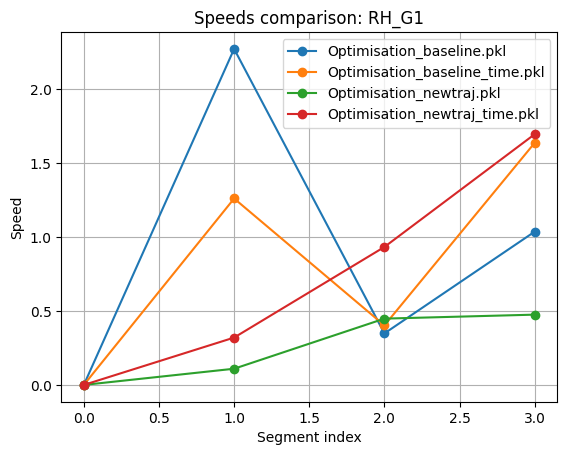

In [33]:
import matplotlib.pyplot as plt

for config, datasets in plot_data.items():
    plt.figure()
    
    for label, speeds in datasets.items():
        plt.plot(speeds, marker='o', label=label)
    
    plt.title(f"Speeds comparison: {config}")
    plt.xlabel("Segment index")
    plt.ylabel("Speed")
    plt.legend()
    plt.grid()
    
    plt.show()

Plotting of the actual simulated speeds.

In [58]:
def run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt):
    # Create mesh and cloth instance
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"{cloth_name}_{grasp_name}")
    
    dt = cloth.estimateTimeStep(L=0.9)

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()
    
    # ---------- Stabilisation ----------
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)
    
    p0 = cloth.positions[inds_ctr].copy()
    
    # ---------- Generate lambda sequence ----------
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    
    # We'll store the positions of the controlled nodes at each step
    ctrl_pos_history = [p0.copy()]
    # Record start index for motion phase
    motion_start_idx = len(cloth.history_pos)  # Current history length before motion

    # Motion phase
    for i in range(len(lam_seq)-1):
        target = p0 + path_displacement(lam_seq[i+1])
        cloth.simulate(u=target, control=inds_ctr)
        ctrl_pos_history.append(cloth.positions[inds_ctr].copy())
    
    # Record end index for motion phase
    motion_end_idx = len(cloth.history_pos)

    # ---------- Release phase ----------
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)
    
    # Get full history
    history_pos = np.array(cloth.history_pos)
    history_vel = np.array(cloth.history_vel)
       
    # Extract motion phase only (aligned with lam_seq)
    motion_pos = history_pos[motion_start_idx:motion_end_idx]
    motion_vel = history_vel[motion_start_idx:motion_end_idx]

    print(f"  Motion steps: {len(motion_pos)}")
    print(f"  Lambda steps: {len(lam_seq)}")

    # Verify alignment
    if len(motion_pos) != len(lam_seq):
        print(f"  WARNING: Motion steps ({len(motion_pos)}) != trajectory length ({len(lam_seq)})")
        # Trim to smallest
        min_len = min(len(motion_pos), len(lam_seq))
        motion_pos = motion_pos[:min_len]
        motion_vel = motion_vel[:min_len]
        lam_seq = lam_seq[:min_len]

    # Return relevant data
    # Return full history PLUS motion-only data
    return {
        'full_history_pos': history_pos,
        'full_history_vel': history_vel,
        'motion_history_pos': motion_pos,
        'motion_history_vel': motion_vel,
        'lam_seq': lam_seq,
        'Am': cloth.Am,
        'label': cloth.label,
        'motion_start_idx': motion_start_idx,
        'motion_end_idx': motion_end_idx,
        'dt': dt}

Based on your mesh, your best dt is: 0.002371335656962282
  Motion steps: 478
  Lambda steps: 479


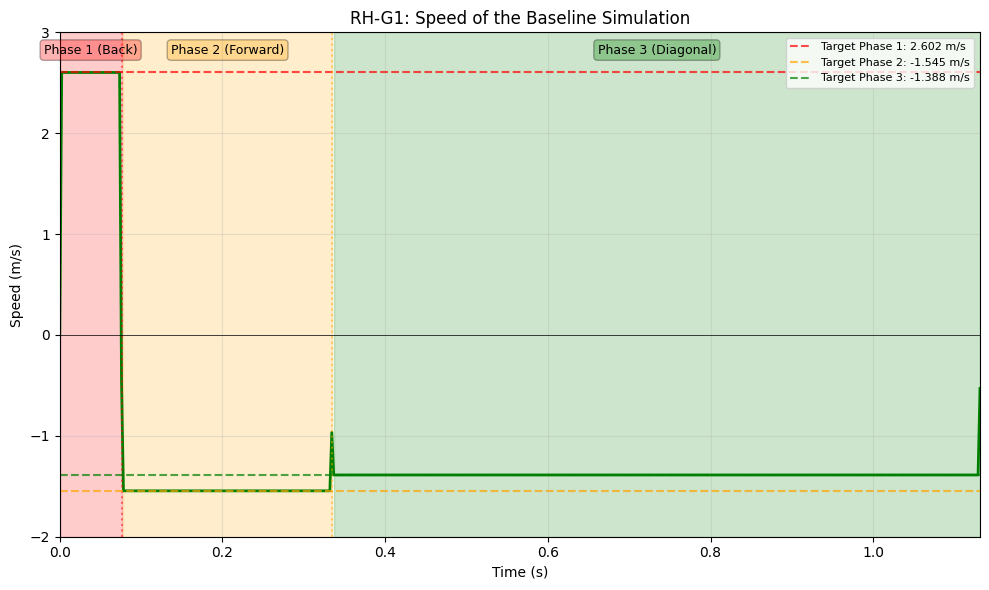

Based on your mesh, your best dt is: 0.002371335656962282
  Motion steps: 469
  Lambda steps: 470


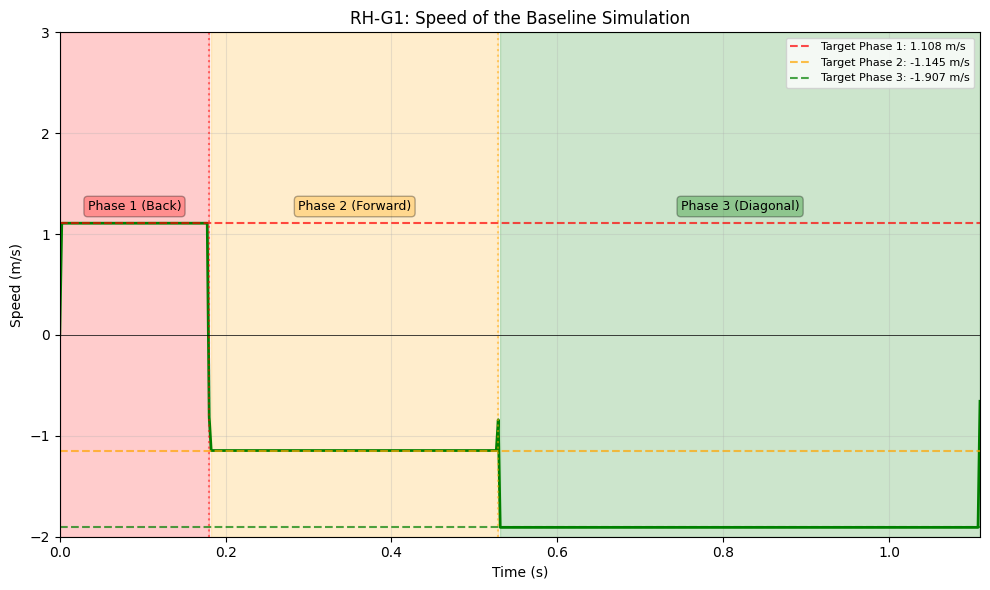

In [78]:
from sklearn.decomposition import PCA

files = [
    'Optimisation_baseline_constant_diffdists.pkl',
    'Optimisation_baseline_constant_diffdists_time_0.01.pkl'
]

for file in files:
    with open(file, 'rb') as f:
        results = pickle.load(f)

    for (cloth_name, grasp_name), data in results.items():
        
        speeds = data['speeds']
        lam_knots = data['lam_knots']

        # Run simulation
        sim_result = run_with_speeds(
            speeds, cloth_name, grasp_name, lam_knots, dt=None
        )

        # Get inds_ctr again (important!)
        _, _, na, _ = create_initial_mesh()
        inds_ctr = get_grasp_config(grasp_name, na)


        history_vel = sim_result['motion_history_vel']
        lam_seq = sim_result['lam_seq']
        lam_pts = [0.0, lam_a, lam_b, 1.0]

        completion = lam_seq

        phase_time_indices = []
        for lam_target in lam_pts[1:]:  # skip 0
            idx = np.searchsorted(completion, lam_target)
            phase_time_indices.append(idx)

        start1 = 1
        end1 = phase_time_indices[0]

        start2 = phase_time_indices[0]
        end2 = phase_time_indices[1]

        start3 = phase_time_indices[1]
        end3 = phase_time_indices[2] if len(phase_time_indices) > 2 else len(lam_seq)


        node = inds_ctr[0]
        vel = history_vel[:, node, :]

        phase1_vel = vel[start1:end1]
        phase2_vel = vel[start2:end2]
        phase3_vel = vel[start3:end3]

        y_dir = np.array([0, 1, 0])

        signed_speed = np.zeros(len(vel))

        # Phase 1 (back → negative naturally)
        signed_speed[start1:end1] = np.dot(phase1_vel, y_dir)

        # Phase 2 (forward → positive)
        signed_speed[start2:end2] = np.dot(phase2_vel, y_dir)

        # Phase 3 → PCA
        pca = PCA(n_components=1)
        pca.fit(phase3_vel)
        diag_dir = pca.components_[0]

        # # FIX SIGN
        # if np.dot(np.mean(phase3_vel, axis=0), diag_dir) < 0:
        #     diag_dir = -diag_dir

        signed_speed[start3:end3] = np.dot(phase3_vel, diag_dir)

        dt = sim_result.get('dt', 0.005)
        motion_time = np.arange(len(signed_speed)) * dt

        # Opt. speeds in m/s (as simulator uses) -> m/s = (lam/s)*(L1+L2+L3)
        speeds_ms = []
        for i in speeds:
            speeds_ms.append((L1+L2+L3)*i)

        fig, axes = plt.subplots(1, 1, figsize=(10, 6))

        axes.plot(motion_time, signed_speed, 'g-', linewidth=2)

        axes.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

        colors = ['red', 'orange', 'green']
        phase_names = ['Phase 1 (Back)', 'Phase 2 (Forward)', 'Phase 3 (Diagonal)']

        start_idx = 0

        for i in range(3):
            end_idx = phase_time_indices[i] if i < len(phase_time_indices) else len(signed_speed)

            if start_idx < end_idx:
                t_start = motion_time[start_idx]
                t_end = motion_time[end_idx - 1] if end_idx < len(motion_time) else motion_time[-1]

                # Background color
                axes.axvspan(t_start, t_end, alpha=0.2, color=colors[i])

                # Label
                mid_time = (t_start + t_end) / 2
                axes.text(mid_time, axes.get_ylim()[1]-0.02,
                        phase_names[i],
                        ha='center', fontsize=9,
                        bbox=dict(boxstyle="round", facecolor=colors[i], alpha=0.3))
                
                # Target lines with appropriate signs
                if i == 0:  # Phase 1: Back (negative)
                    axes.axhline(y=speeds_ms[i], color=colors[i], linestyle='--', alpha=0.7,
                                label=f'Target Phase {i+1}: {speeds_ms[i]:.3f} m/s')
                else:  # Phases 2 and 3: Forward (positive)
                    axes.axhline(y=-speeds_ms[i], color=colors[i], linestyle='--', alpha=0.7,
                                label=f'Target Phase {i+1}: {-speeds_ms[i]:.3f} m/s')

                    
                # Vertical boundary
                if i < 2:
                    axes.axvline(x=t_end, color=colors[i], linestyle=':', alpha=0.5)

            start_idx = end_idx

        axes.set_xlabel('Time (s)')
        axes.set_ylabel('Speed (m/s)')
        axes.set_title(f'{cloth_name}-{grasp_name}: Speed of the Baseline Simulation')
        axes.legend(loc='upper right', fontsize=8)
        axes.grid(True, alpha=0.3)
        axes.set_xlim([0, motion_time[-1]])
        axes.set_ylim([-2, 3])

        plt.tight_layout()
        plt.show()

In [80]:
# Total time
print(f'Total motion time baseline:{479*dt}')
print(f'Total motion time baseline w/ time penaly:{465*dt}')
print(f'Total motion time baseline w/ time penaly (0.02):{450*dt}')


Total motion time baseline:1.135869779684933
Total motion time baseline w/ time penaly:1.102671080487461
Total motion time baseline w/ time penaly (0.02):1.0671010456330268


In [ ]:
# Convert lam/s speeds to m/s speeds as simulator does!

speeds_ms = []
for i in speeds:
    speeds_ms.append((L1+L2+L3)*i)

print(speeds_ms)

[np.float64(2.216637723862433), np.float64(1.425960278863803), np.float64(1.7262032158670133)]


Plotting of the trajectories with speed mapping

In [31]:
def run_simulation_record_trajectory(best_speeds, cloth_name, grasp_name, lam_knots, dt_fixed):
    """
    Re-runs simulation with optimal speeds, recording positions and lambda speed
    at each step for trajectory plotting.
    Returns: dict with 'positions' (n_steps, n_nodes, 3) and 'speeds' (n_steps,)
    """
    import numpy as np

    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"traj_{cloth_name}_{grasp_name}")
    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)
    dt = dt_fixed

    cloth.setSimulatorParameters(
        dt=dt, tol=params["tol"], rho=params["rho"],
        delta=params["delta"], alpha=params["alpha"], kappa=params["kappa"],
        str=params["str"], shr=params["shr"], mu_f=params["mu_f"],
        mu_s=params["mu_s"], thck=params["thck"],
    )
    cloth.restart()

    # Stabilisation
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)

    p0 = cloth.positions[inds_ctr].copy()
    lam_seq = generate_lambda_sequence(best_speeds, lam_knots, dt)

    # Record trajectory
    positions_over_time = []   # position of every node at each step
    speed_at_step = []         # lambda speed at each step

    for i in range(len(lam_seq) - 1):
        lam_cur = lam_seq[i]
        lam_next = lam_seq[i + 1]
        target = p0 + path_displacement(lam_next)
        cloth.simulate(u=target, control=inds_ctr)

        positions_over_time.append(cloth.positions.copy())   # shape: (n_nodes, 3)
        dlam = lam_next - lam_cur
        speed_at_step.append(cloth.velocities.copy()) # lambda-space speed (1/s)

    return {
        "positions": np.array(positions_over_time),   # (n_steps, n_nodes, 3)
        "speeds": np.array(speed_at_step),            # (n_steps,)
        "lam_seq": lam_seq,
        "dt": dt,
    }

In [37]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def plot_node_trajectory_3d_colorspeed(traj_data, node_id=0, figsize=(9, 7),
                                        cmap_name="plasma", elev=25, azim=45):
    """
    3D trajectory of a single node colored by lambda speed.

    elev, azim: initial camera angles (degrees) — adjust to best view your cloth.
    """
    positions = traj_data["positions"]   # (n_steps, n_nodes, 3)
    speeds    = traj_data["speeds"]      # (n_steps,)

    node_pos = positions[:, node_id, :]  # (n_steps, 3)
    node_vel = speeds[:, node_id, :]          # (n_steps, 3)
    speeds = np.linalg.norm(node_vel, axis=1)  # (n_steps,) — magnitude
    x = node_pos[:, 0]
    y = node_pos[:, 1]
    z = node_pos[:, 2]

    # hard-code limits so all have the same bar!
    norm = mcolors.Normalize(vmin=0, vmax=2.3)
    cmap = cm.get_cmap(cmap_name)

    # Build Line3DCollection — one segment per step
    points = np.stack([x, y, z], axis=1)             # (n_steps, 3)
    segments = np.stack([points[:-1], points[1:]], axis=1)  # (n_steps-1, 2, 3)
    colors = cmap(norm(speeds[:-1]))                  # one color per segment

    # thicker lines when speed is high
    speed_threshold = 1.8

    linewidths = np.where(
        speeds[:-1] > speed_threshold,
        4,   # thick line
        2    # normal line
    )

    lc = Line3DCollection(segments, colors=colors, linewidth=linewidths)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(lc)

    # Start / end markers
    ax.scatter(x[0],  y[0],  z[0],  color="green", s=80, zorder=5, label="Start",
               depthshade=False)
    ax.scatter(x[-1], y[-1], z[-1], color="red",   s=80, zorder=5, label="End",
               depthshade=False)

    # Axis limits — must be set manually for Line3DCollection
    for set_lim, data in zip(
        [ax.set_xlim, ax.set_ylim, ax.set_zlim], [x, y, z]
    ):
        pad = ((data.max() - data.min()) or 0.01) * 0.1
        set_lim(np.floor((data.min() - pad) * 100) / 100,
            np.ceil( (data.max() + pad) * 100) / 100)

    ax.set_ylim(-0.75, 0.35) 
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.1, label="Lambda speed (λ/s)")

    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title("Trajectory with the Speed Mapping")
    ax.legend()
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

    return fig

/var/folders/l5/4jphj2ns2zj_nmbq6c0y64p00000gn/T/ipykernel_3258/2637710422.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


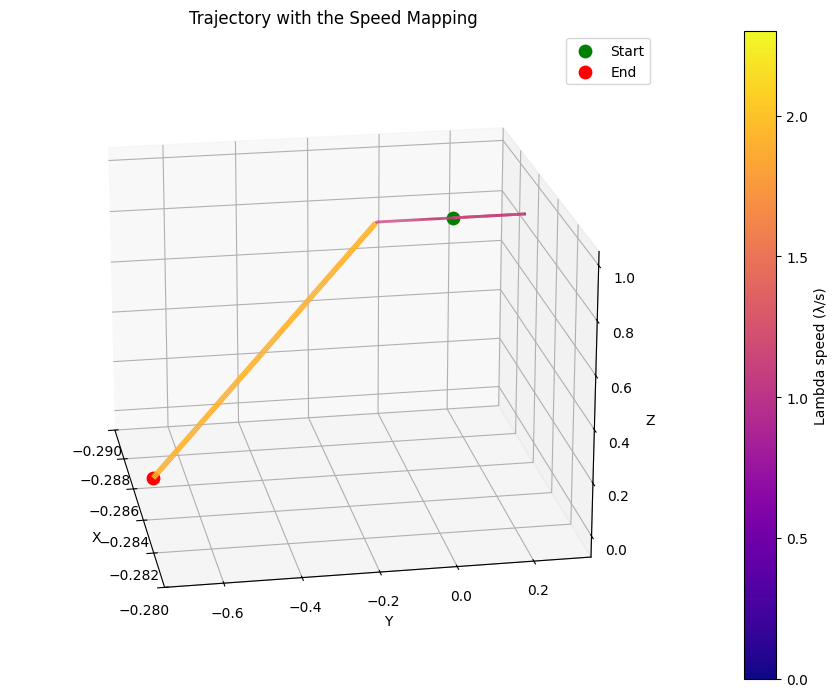

In [38]:
# Load your results
import pickle
with open("Optimisation_baseline_constant_time_diffdists.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)

# Plot node 0 trajectory with speed colormap
fig = plot_node_trajectory_3d_colorspeed(traj, node_id=0, elev=20, azim=-10)

name = "Traj_Speed_Baseline_Time.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

/var/folders/l5/4jphj2ns2zj_nmbq6c0y64p00000gn/T/ipykernel_3258/2637710422.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


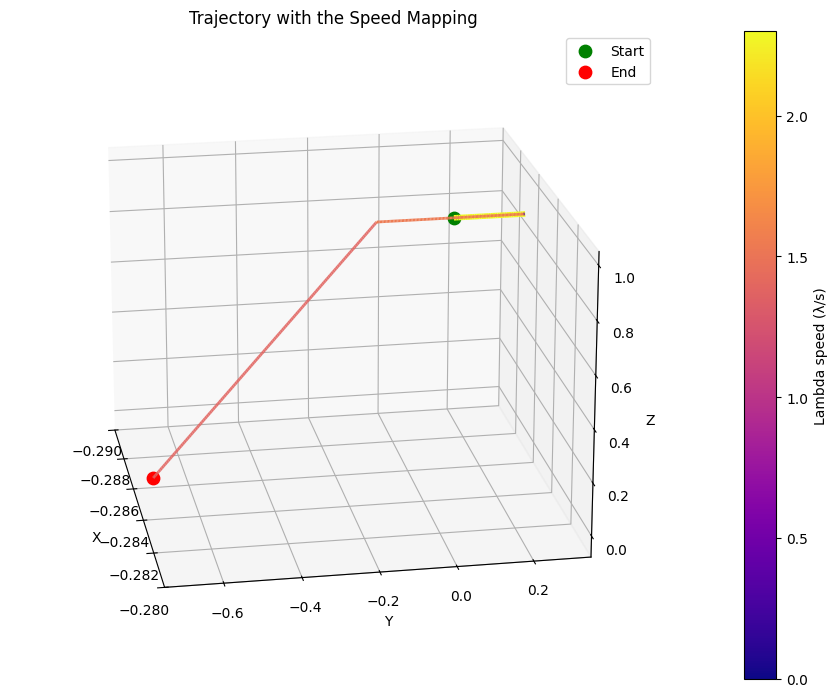

In [39]:
# Load your results
import pickle
with open("Optimisation_baseline_constant_diffdists.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)

# Plot node 0 trajectory with speed colormap
fig = plot_node_trajectory_3d_colorspeed(traj, node_id=0, elev=20, azim=-10)

name = "Traj_Speed_Baseline.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

Plot lambda progression for speed profile

In [29]:
def plot_lambda_progression(traj_data, lam_knots, cloth_name, grasp_name, figsize=(8, 4)):
    lam_seq = np.array(traj_data["lam_seq"])  # (n_steps+1,)
    dt = traj_data["dt"]
    time_vec = np.arange(len(lam_seq)) * dt

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(time_vec, lam_seq, color="steelblue", linewidth=1.5)

    # Phase transition lines
    for i, lk in enumerate(lam_knots):
        ax.axhline(lk, color="gray", linestyle="--", linewidth=0.8)
        ax.text(time_vec[-1] * 1.01, lk, f"λ={lk:.3f}", fontsize=8,
                color="gray", va="center")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lambda (λ)")
    ax.set_ylim(0, 1)
    ax.set_xlim(time_vec[0], time_vec[-1])
    ax.set_title(f"Lambda progression")
    
    phase_colors = ['red', 'orange', 'green']
    boundaries = [0, lam_knots[1], lam_knots[2], 1.0]
    for i in range(3):
        # find time where lam crosses each boundary
        t_start = time_vec[np.searchsorted(lam_seq, boundaries[i])]
        t_end   = time_vec[np.searchsorted(lam_seq, boundaries[i+1]) - 1]
        ax.axvspan(t_start, t_end, color=phase_colors[i], alpha=0.25,
                   label=f"Phase {i+1}")
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()
    
    return fig

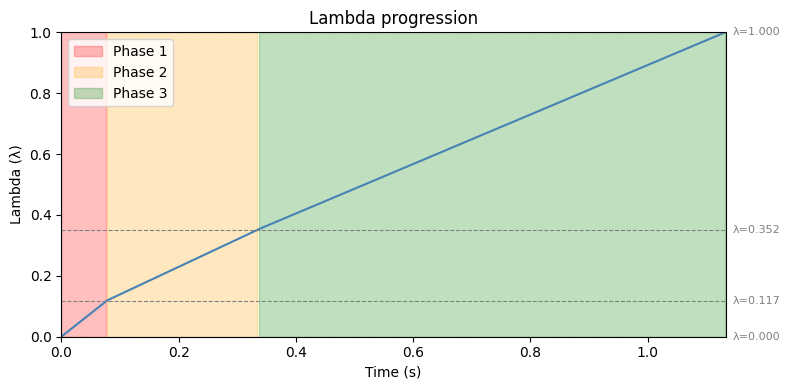

In [32]:
# Load your results
import pickle
with open("Optimisation_baseline_constant_diffdists.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)


fig = plot_lambda_progression(traj, lam_knots, cloth_name, grasp_name)
name = "LamProgr_Baseline_SpeedOpt_Constant.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

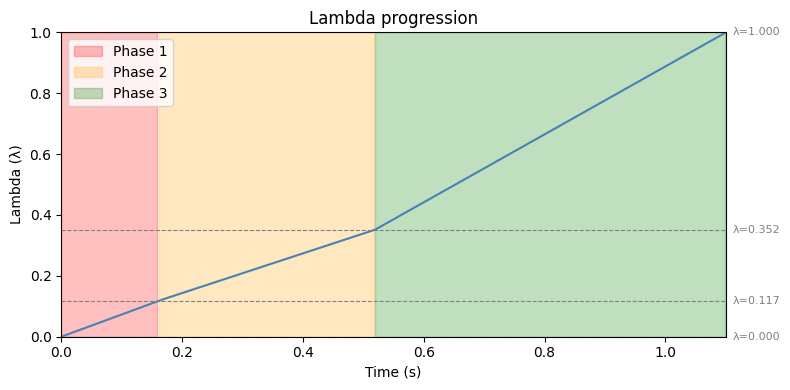

In [33]:
# Load your results
import pickle
with open("Optimisation_baseline_constant_time_diffdists.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)


fig = plot_lambda_progression(traj, lam_knots, cloth_name, grasp_name)
name = "LamProgr_Baseline_SpeedOpt_Time_Constant.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

Get actual simulation times vs. ideally calculated ones

In [ ]:
best_speeds = [0.0, 1.33, 0.51, 0.89] # no time
# best_speeds = [0.0, 1.33, 0.86, 1.04] # time
lam_seq = generate_lambda_sequence(best_speeds, lam_knots, dt)
T_sim        = (len(lam_seq) - 1) * dt
T_analytical = L1/best_speeds[1] + L2/best_speeds[2] + L3/best_speeds[3]
print(f"Sim time:        {T_sim:.4f} s")
print(f"Analytical time: {T_analytical:.4f} s")
print(f"Difference:      {T_sim - T_analytical:.4f} s")

Sim time:        11.8567 s
Analytical time: 2.1281 s
Difference:      9.7286 s


: 

### Report Visuals

Plot Lambda Progression Representation

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lambda_progression_example(lam_a, lam_b):

    # ---------------------------------
    # Construct illustrative lambda(t)
    # ---------------------------------

    # Phase 1: slow
    t1 = np.linspace(0, 1.5, 80)
    lam1 = np.linspace(0, lam_a, len(t1))

    # Phase 2: very fast
    t2 = np.linspace(t1[-1], 2.0, 25)
    lam2 = np.linspace(lam_a, lam_b, len(t2))

    # Phase 3: much slower
    t3 = np.linspace(t2[-1], 3.0, 140)
    lam3 = np.linspace(lam_b, 1.0, len(t3))

    # Combine
    time = np.concatenate([t1, t2[1:], t3[1:]])
    lam_seq = np.concatenate([lam1, lam2[1:], lam3[1:]])

    # ---------------------------------
    # Plot
    # ---------------------------------

    fig, ax = plt.subplots(figsize=(8,4))

    ax.plot(
        time,
        lam_seq,
        linewidth=2.5,
        color='black'
    )

    # ---------------------------------
    # Phase background shading
    # ---------------------------------

    ax.axvspan(0, 1.5, color='red', alpha=0.08, label='Phase 1')
    ax.axvspan(1.5, 2.0, color='green', alpha=0.08, label='Phase 2')
    ax.axvspan(2.0, 3.0, color='blue', alpha=0.08, label='Phase 3')

    # ---------------------------------
    # Vertical phase boundaries
    # ---------------------------------

    ax.axvline(1.5, color='red', linestyle='--', alpha=0.5)
    ax.axvline(2.0, color='green', linestyle='--', alpha=0.5)

    # ---------------------------------
    # Phase boundaries
    # ---------------------------------

    ax.axhline(
        lam_a,
        color='orange',
        linestyle='--',
        alpha=0.8
    )

    ax.axhline(
        lam_b,
        color='purple',
        linestyle='--',
        alpha=0.8
    )

    # ---------------------------------
    # Labels
    # ---------------------------------

    ax.text(
        0.1,
        lam_a + 0.02,
        fr'$\lambda_a$ = {lam_a:.3f}',
        color='orange',
        fontsize=11
    )

    ax.text(
        0.1,
        lam_b + 0.02,
        fr'$\lambda_b$ = {lam_b:.3f}',
        color='purple',
        fontsize=11
    )

    # ---------------------------------
    # Optional phase labels
    # ---------------------------------

    ax.text(
        0.2,
        lam_a/2,
        'Phase 1',
        fontsize=10
    )

    ax.text(
        1.7,
        (lam_a + lam_b)/2-0.08,
        'Phase 2',
        fontsize=10
    )

    ax.text(
        2.6,
        (lam_b + 1.0)/2,
        'Phase 3',
        fontsize=10
    )

    # ---------------------------------
    # Formatting
    # ---------------------------------

    ax.set_xlabel('Time [s]')
    ax.set_ylabel(r'Path progression $\lambda$')

    ax.set_xlim(0, 3.0)
    ax.set_ylim(0, 1.05)

    ax.grid(True, alpha=0.3)

    ax.set_title(
        'Illustrative progression along the normalized trajectory path'
    )

    plt.tight_layout()
    plt.show()

    return fig

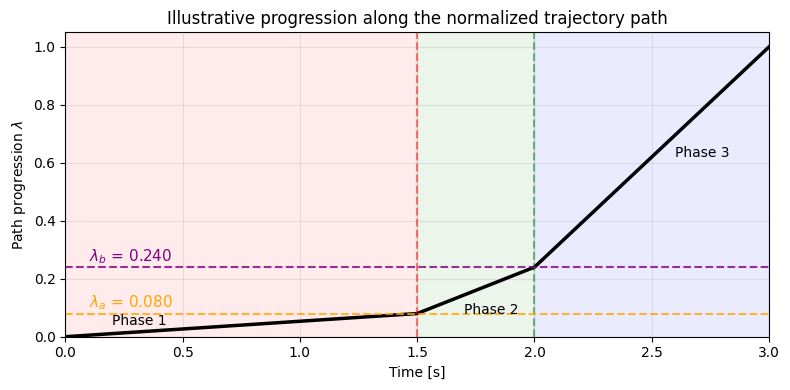

In [32]:
lam_a = 0.08
lam_b = 0.24

fig = plot_lambda_progression_example(lam_a, lam_b)

name = "LamProgress_Repr.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

Plot Trajectory Parametrization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh_with_grasp_and_traj(X, T, inds_ctr, d=0.1, theta_deg=45, title="Mesh"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # --- Mesh ---
    triangles = X[T]
    mesh = Poly3DCollection(triangles, alpha=0.45, zorder=1)
    mesh.set_facecolor('lightblue')
    mesh.set_edgecolor('none')
    mesh.set_linewidth(0.3)
    ax.add_collection3d(mesh)

    inds_ctr = [inds_ctr[0]]
    
    # --- Offset grasp points (visibility fix) ---
    offset = -0.01
    X_offset = X.copy()
    X_offset[inds_ctr, 1] += offset  # along Z
    
    ax.scatter(
        X_offset[inds_ctr, 0],
        X_offset[inds_ctr, 1],
        X_offset[inds_ctr, 2],
        color='red',
        s=10,
        depthshade=False
    )
    
    # =========================
    # 🚀 TRAJECTORIES (ALL NODES)
    # =========================
    
    theta = np.radians(theta_deg)
    
    dir_z = np.array([0.0, 1.0, 0.0])   # back-forth (Z)
    dir_y = np.array([0.0, 0.0, 1.0])  # down (Y)
    
    table_y = np.min(X[:,2])

    label_idx = inds_ctr[0]
    
    for idx in inds_ctr:
        p0 = X[idx].copy()
        
        # 1. backward
        p1 = p0 - d * dir_z
        phase1 = d
        
        # 2. forward
        p2 = p1 + 2 * d * dir_z # 1rst baseline traj
        phase2 = 2*d
        # p2 = p1 + d/2 * dir_z # 2nd traj
        
        # 3. diagonal down
        h = p2[2] - table_y
        dz = abs(h) / np.tan(theta)
        dy = -h
        
        p3 = p2 + dz * dir_z + dy * dir_y
        phase3 = np.sqrt(dz**2+dy**2)

        # lambdas
        lam_a = phase1 / (phase1+phase2+phase3)
        lam_b = (phase1+phase2) / (phase1+phase2+phase3)
        
        # Apply same offset for visibility
        p0[1] += offset
        p1[1] += offset
        p2[1] += offset
        p3[1] += offset
        
        # --- Plot each phase with different color ---
        
        # Backward (red)
        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            [p0[2], p1[2]],
            color='red',
            linewidth=2.5
        )
        
        # Forward (green)
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            color='green',
            linewidth=1
        )
        
        # Downward diagonal (blue)
        ax.plot(
            [p2[0], p3[0]],
            [p2[1], p3[1]],
            [p2[2], p3[2]],
            color='blue',
            linewidth=1
        )

        if idx == label_idx:
            # ----------------------------
            # Lambda knot labels
            # ----------------------------
            ax.text(
                p0[0],
                p0[1]+0.02,
                p0[2]+0.04,
                r'$\lambda = 0$',
                fontsize=11
            )

            ax.text(
                p1[0],
                p1[1]-0.02,
                p1[2],
                fr'$\lambda_a$ = {lam_a:.2f}',
                fontsize=11
            )

            ax.text(
                p2[0],
                p2[1]+0.15,
                p2[2]+0.04,
                fr'$\lambda_b$ = {lam_b:.2f}',
                fontsize=11
            )

            ax.text(
                p3[0],
                p3[1]-0.02,
                p3[2],
                r'$\lambda = 1$',
                fontsize=11
            )

            # ----------------------------
            # Lambda knot points
            # ----------------------------
            lambda_points = np.array([p0, p1, p2, p3])

            ax.scatter(
            lambda_points[:,0],
            lambda_points[:,1],
            lambda_points[:,2],
            facecolors='white',
            edgecolors='black',
            s=60,
            linewidths=1.5,
            depthshade=False,
            zorder=10)

    # --- Formatting ---
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=10, azim=180)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(-0.1,0.5)
    ax.set_zticks([])
    ax.grid(False)

    ax.plot([], [], [], color='red', label='$L_1$')
    ax.plot([], [], [], color='green', label='$L_2$')
    ax.plot([], [], [], color='blue', label='$L_3$')
    ax.legend()
    
    ax.set_title(title)
    plt.show()

    return fig

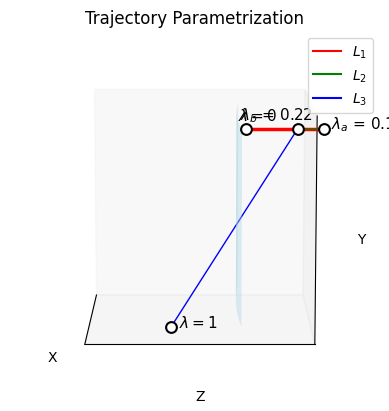

In [ ]:
X, T, na, nb = create_initial_mesh()

grasp_list = ["G1"] # only G1 for trajectory plotting

for grasp_name in grasp_list:
    inds_ctr = get_grasp_config(grasp_name, na)
    
    fig = plot_mesh_with_grasp_and_traj(
    X, T, inds_ctr,
    d=0.1,
    theta_deg=75,
    title="Trajectory Parametrization")

    name = "Traj_Param_I.png"
    fig.savefig(name, dpi=300, bbox_inches='tight')

    
